In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import time
import numpy as np
from Shapley import ShapNN
from DShap import DShap
import matplotlib.pyplot as plt
import sklearn
from shap_utils import *
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore")
%matplotlib inline
MEM_DIR = './'
problem, model = 'classification', 'vyngoc' # 'logistic'
hidden_units = [] # Empty list in the case of logistic regression.
train_size = 100
d, difficulty = 50, 1
num_classes = 2
tol = 0.03
target_accuracy = 0.62
important_dims = 5
clf = return_model(model, solver='liblinear', hidden_units=tuple(hidden_units))
_param = 1.0
for _ in range(100):
    X_raw = np.random.multivariate_normal(mean=np.zeros(d), cov = np.eye(d), 
                                          size=train_size + 5000)
    _, y_raw, _, _ = label_generator(
        problem, X_raw, param = _param,  difficulty = difficulty, important=important_dims)
    clf.fit(X_raw[:train_size], y_raw[:train_size])
    test_acc = clf.score(X_raw[train_size:], y_raw[train_size:])
    if test_acc > target_accuracy:
        break
    _param *= 1.1
X, y = X_raw[:train_size], y_raw[:train_size]
X_test, y_test = X_raw[train_size:], y_raw[train_size:]
model = 'vyngoc'
problem = 'classification'
num_test = 1000
directory = './synthetic_data_results'
print("Full Data Size:", len(y_raw))
print("Training Data Size:", len(y))
print("Test Size:", len(y_test))
print("Performance using the whole training set = {:.2f}".format(test_acc))
print("Training class counts:", np.bincount(y))
print("Test class counts:", np.bincount(y_test))

2026-05-06 11:41:52.290809: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 11:41:52.871811: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Instructions for updating:
non-resource variables are not supported in the long term
Full Data Size: 5100
Training Data Size: 100
Test Size: 5000
Performance using the whole training set = 0.63
Training class counts: [47 53]
Test class counts: [2574 2426]


In [2]:
import pandas as pd
train_df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
train_df['label'] = y
test_df = pd.DataFrame(X_test, columns=[f"feature_{i}" for i in range(X_test.shape[1])])
test_df['label'] = y_test
# In DataFrame
print("=== Training DataFrame ===")
print(train_df)
print("\n=== Test DataFrame ===")
print(test_df)

=== Training DataFrame ===
    feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   -0.612758   0.324650   1.324203   0.115556  -1.775641  -1.246072   
1   -0.333224   0.420818  -0.516589  -1.172375   1.014576   1.054571   
2    0.689493  -0.371268   0.058635  -1.688980  -1.955941  -0.163242   
3    1.786645  -1.287544  -0.101731   0.908893  -0.493265   0.999835   
4    1.314194   0.295143  -0.776340  -0.124338   1.085366  -0.609249   
..        ...        ...        ...        ...        ...        ...   
95   0.151202  -1.501587   0.871843  -0.090272   0.404135   0.688945   
96   2.744239   0.064956   1.405464  -0.726020  -1.323702  -1.250760   
97  -0.160717   0.508124  -0.116171  -1.198972  -0.156977  -0.921053   
98  -0.489778   0.523463   0.526342   0.016174  -0.491727  -1.380716   
99   1.830195  -1.721194   0.133608  -2.515665  -1.037081  -1.149110   

    feature_6  feature_7  feature_8  feature_9  ...  feature_41  feature_42  \
0    0.328853   0.625121   0.

In [3]:
print("=== Training set statistics ===")
train_stats = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
train_stats['label'] = y
print(train_stats.describe())
print("\n=== Test set statistics ===")
test_stats = pd.DataFrame(X_test, columns=[f"feature_{i}" for i in range(X_test.shape[1])])
test_stats['label'] = y_test
print(test_stats.describe())

=== Training set statistics ===
        feature_0   feature_1   feature_2   feature_3   feature_4   feature_5  \
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000   
mean     0.167613   -0.007530    0.204009   -0.074190   -0.057576   -0.022392   
std      1.058126    0.984682    0.864878    1.053994    0.923902    1.068814   
min     -1.943541   -3.468465   -1.902292   -3.079248   -2.952069   -2.409329   
25%     -0.506372   -0.566588   -0.402438   -0.735346   -0.637174   -0.797326   
50%      0.016341    0.011491    0.150622   -0.068005   -0.132253   -0.050562   
75%      0.873574    0.531465    0.838598    0.774853    0.566901    0.671370   
max      2.907473    2.816098    2.246838    2.321115    2.084467    4.202688   

        feature_6   feature_7   feature_8   feature_9  ...  feature_41  \
count  100.000000  100.000000  100.000000  100.000000  ...  100.000000   
mean     0.089360   -0.268435    0.073913   -0.108748  ...    0.093807   
std      0.88343

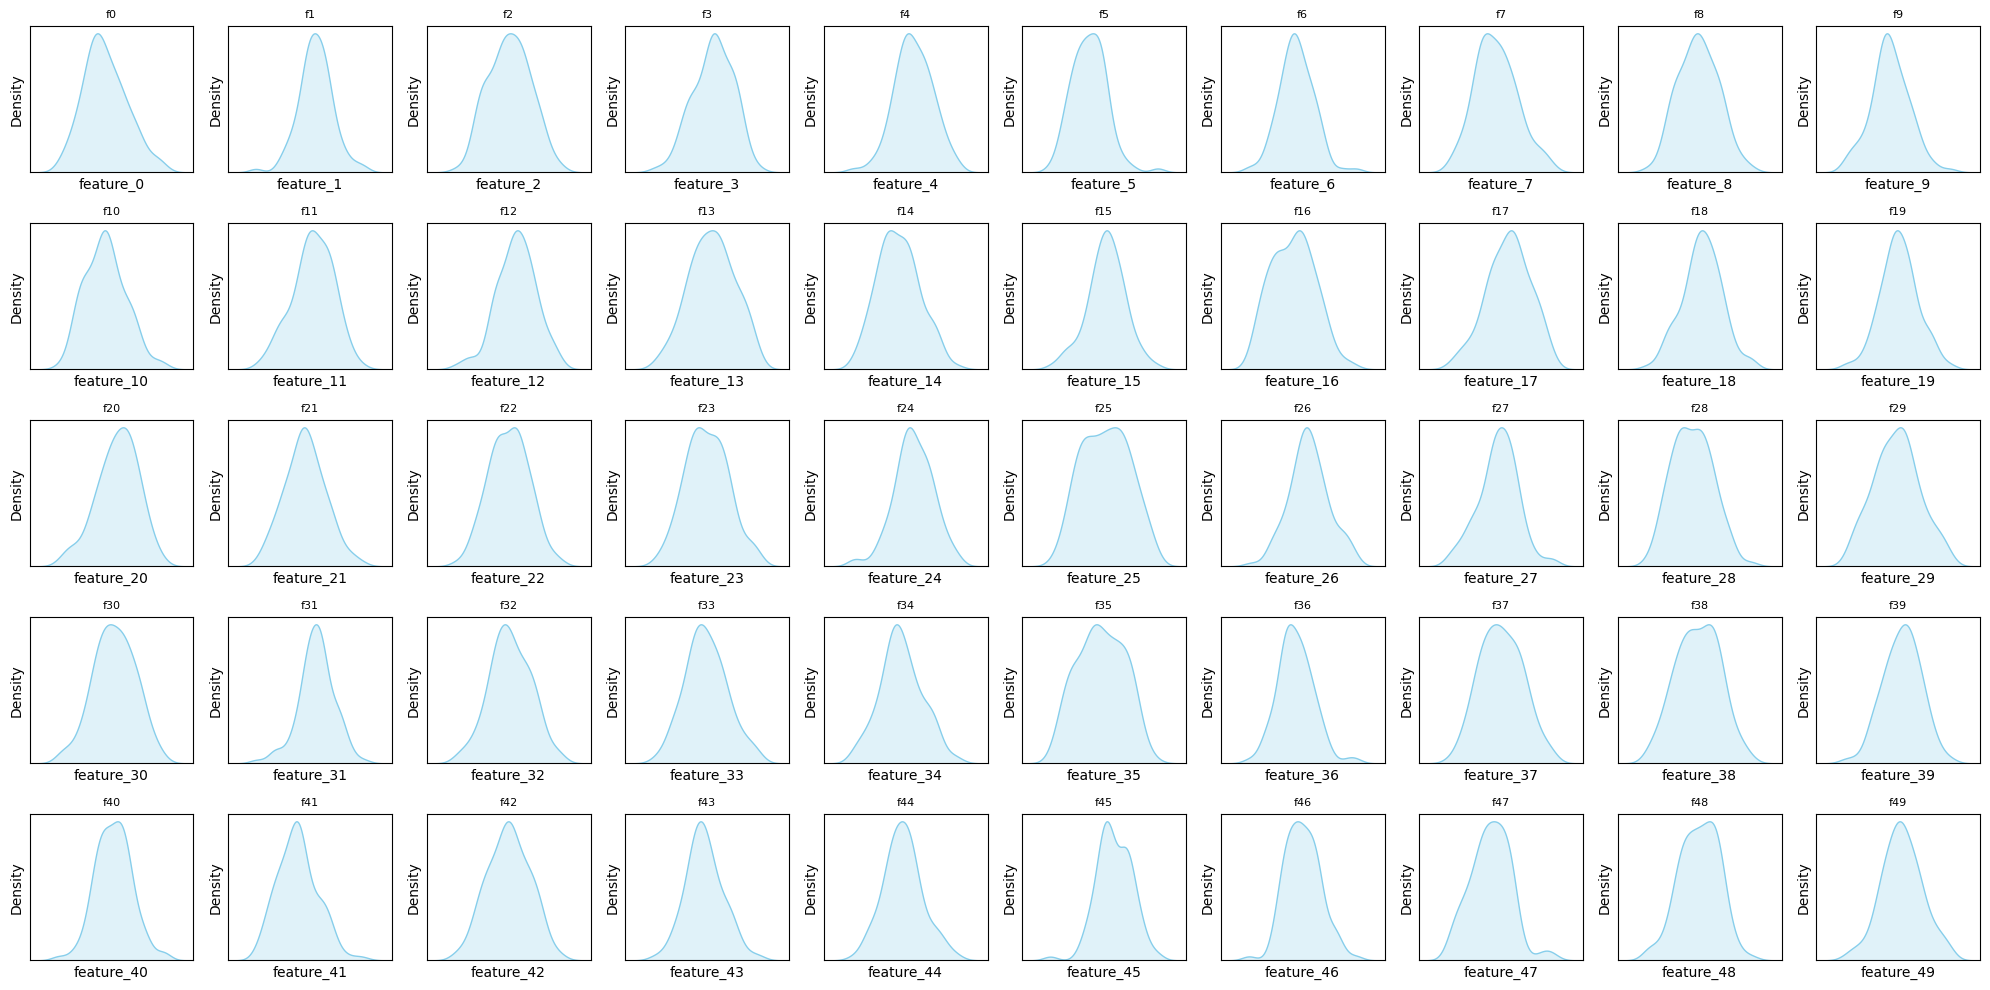

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
num_features = X.shape[1]  # 50
cols = 10  
rows = int(np.ceil(num_features / cols))  
plt.figure(figsize=(20, 10))  
for i in range(num_features):
    plt.subplot(rows, cols, i+1)
    sns.kdeplot(train_df[f"feature_{i}"], fill=True, color='skyblue')
    plt.title(f'f{i}', fontsize=8)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

In [5]:
dshap = DShap(X, y, X_test, y_test, num_test, 
              sources=None, 
              sample_weight=None,
              model_family=model, 
              metric='accuracy',
              overwrite=True,
              directory=directory, seed=0)
dshap.run(100, 0.1)
dshap = DShap(X, y, X_test, y_test, num_test, model_family=model, metric='accuracy',
              directory=directory, seed=1)
dshap.run(100, 0.1)
dshap = DShap(X, y, X_test, y_test, num_test, model_family=model, metric='accuracy',
              directory=directory, seed=2)
dshap.run(100, 0.1)
dshap.merge_results()

Starting LOO score calculations!
LOO values calculated!


2026-05-06 11:41:56.936138: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-06 11:41:56.936584: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-05-06 11:41:57.011378: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-05-06 11:41:57.023214: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} 

2026-05-06 11:41:57.388898: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-06 11:41:57.389017: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-05-06 11:41:57.425366: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true,

2026-05-06 11:41:57.840047: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-05-06 11:41:57.847011: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

2026-05-06 11:41:58.272426: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-05-06 11:41:58.279098: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

...

2026-05-06 11:49:09.336603: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-05-06 11:49:09.346215: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

90 out of 100 G-Shapley iterations


2026-05-06 11:49:09.545776: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-05-06 11:49:09.555531: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

2026-05-06 11:49:10.455001: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-05-06 11:49:10.464562: W tensorflow/c/c_api.cc:305] Operation '{name:'final/Db/Assign' id:24 op device:{requested: '', assigned: ''} def:{{{node final/Db/Assign}} = Assign[T=DT_FLOAT, _class=["loc:@final/Db"], _has_manual_control_dependencies=true, use_locking=true, validate_shape=true](final/Db, final/Db/Initializer/Const)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an err

100 out of 100 G-Shapley iterations
10 out of 100 TMC_Shapley iterations.
20 out of 100 TMC_Shapley iterations.
30 out of 100 TMC_Shapley iterations.
40 out of 100 TMC_Shapley iterations.
50 out of 100 TMC_Shapley iterations.
60 out of 100 TMC_Shapley iterations.
70 out of 100 TMC_Shapley iterations.
80 out of 100 TMC_Shapley iterations.
90 out of 100 TMC_Shapley iterations.
100 out of 100 TMC_Shapley iterations.
10 out of 100 TMC_Shapley iterations.
20 out of 100 TMC_Shapley iterations.
30 out of 100 TMC_Shapley iterations.
40 out of 100 TMC_Shapley iterations.
50 out of 100 TMC_Shapley iterations.
60 out of 100 TMC_Shapley iterations.
70 out of 100 TMC_Shapley iterations.
80 out of 100 TMC_Shapley iterations.
90 out of 100 TMC_Shapley iterations.
100 out of 100 TMC_Shapley iterations.
./synthetic_data_results/mem_tmc_0000.pkl
./synthetic_data_results/mem_tmc_0002.pkl
./synthetic_data_results/mem_tmc_0001.pkl
./synthetic_data_results/mem_g_0001.pkl
./synthetic_data_results/mem_g_0002.

(None, None)

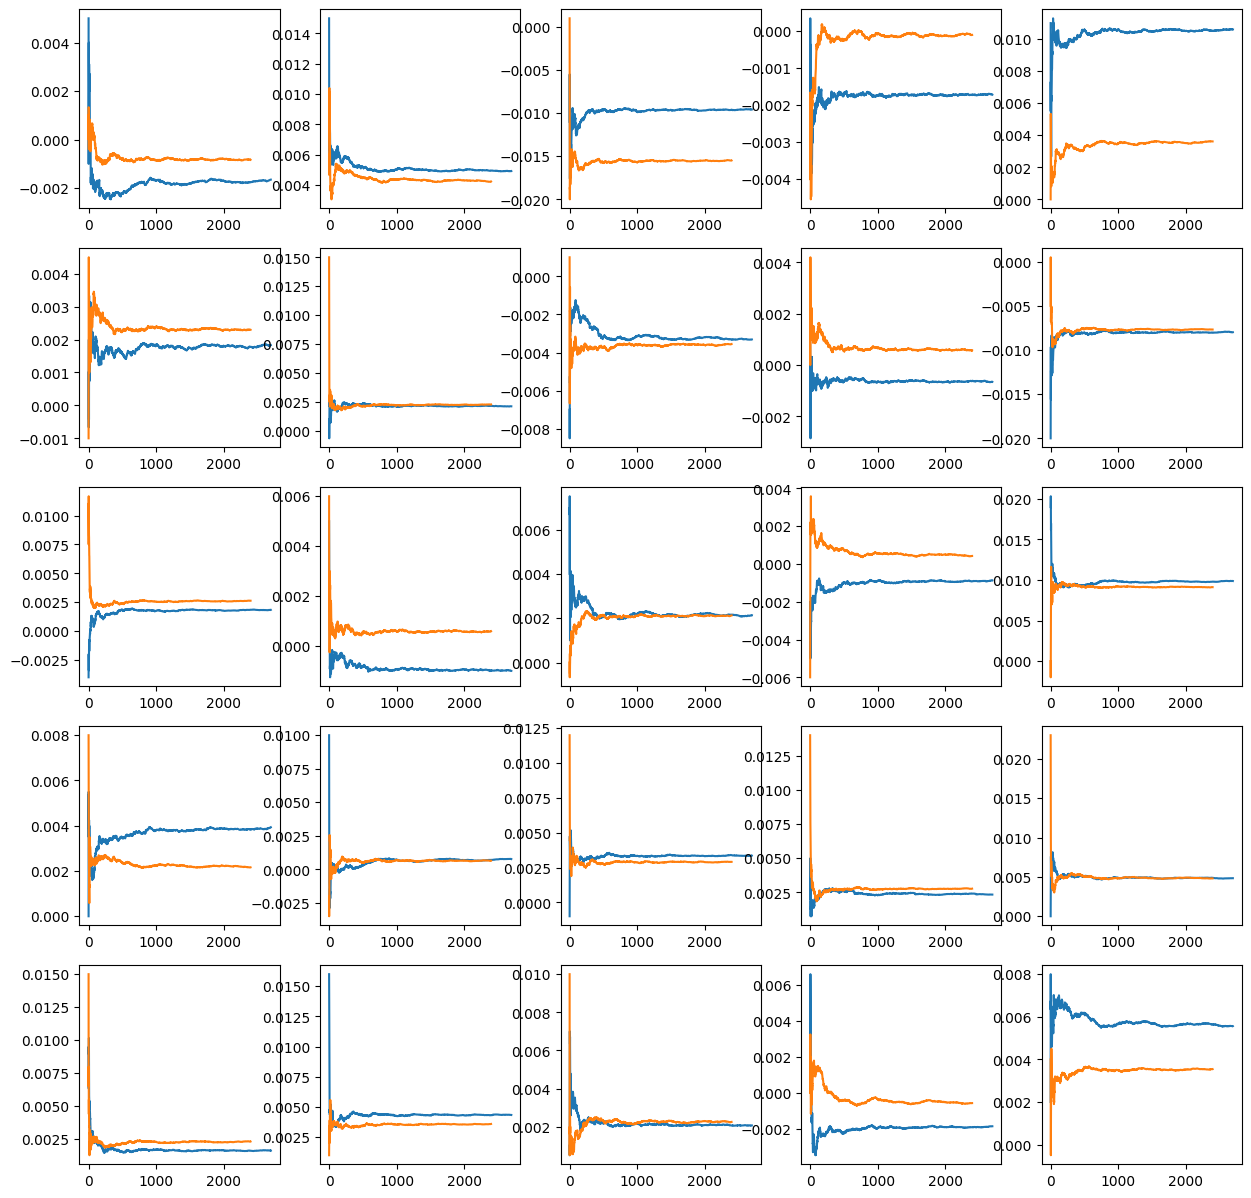

In [6]:
convergence_plots(dshap.marginals_tmc),convergence_plots(dshap.marginals_g)

In [7]:
len(dshap.vals_tmc),len(dshap.vals_g),len(dshap.vals_loo)

(100, 100, 100)

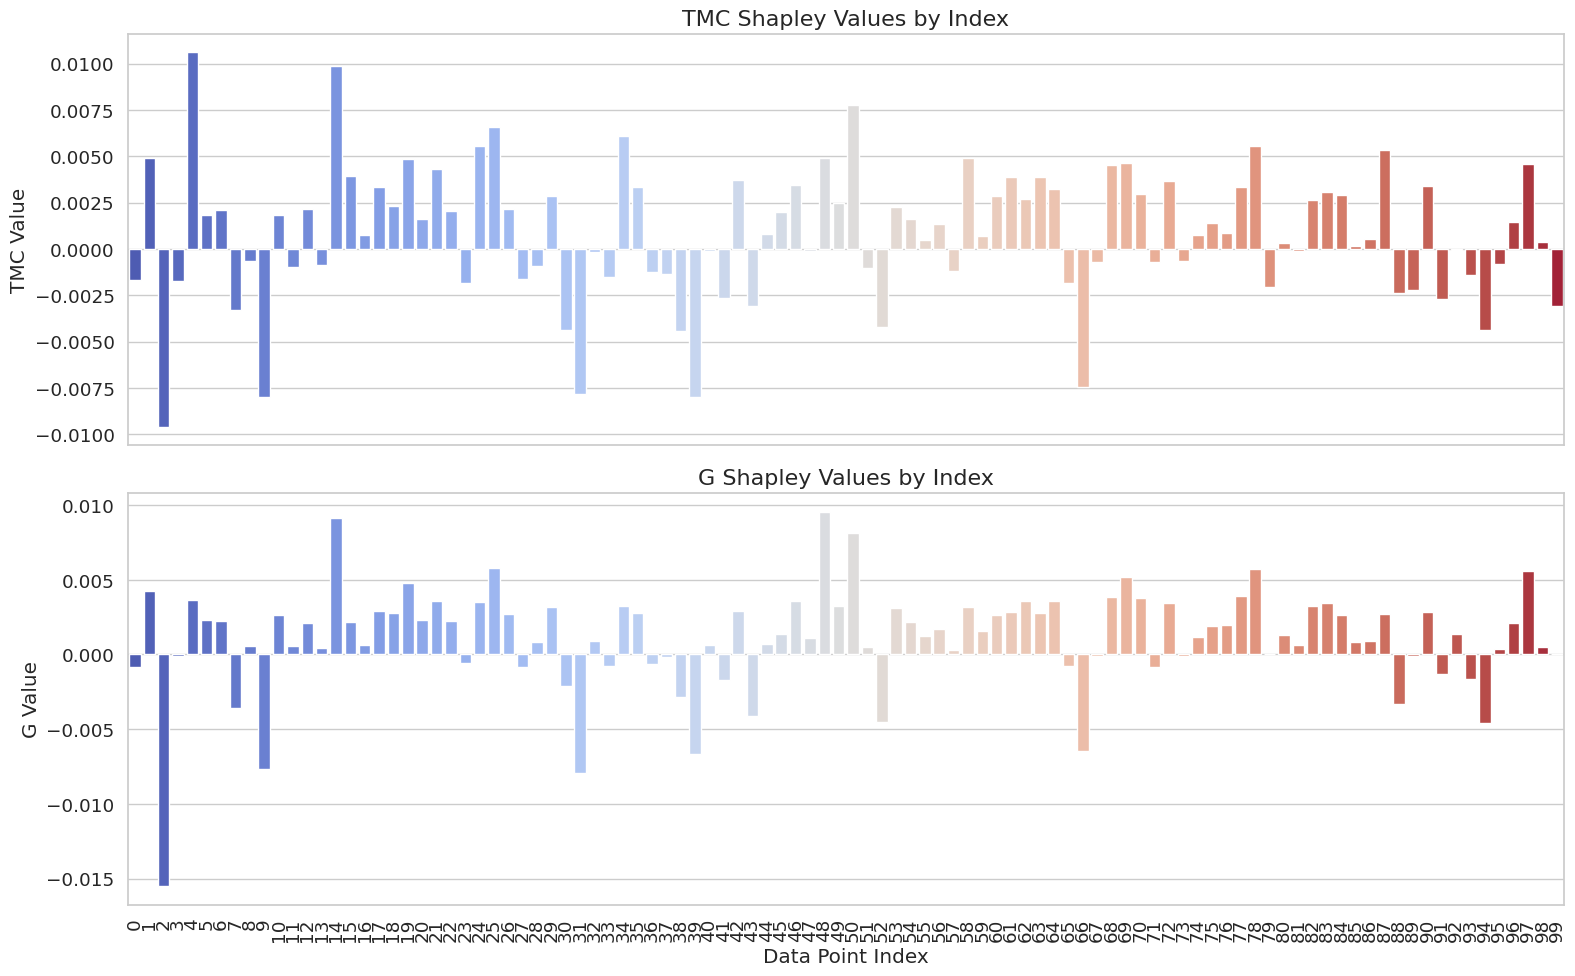

In [8]:
vals_tmc = np.array(dshap.vals_tmc)
vals_g = np.array(dshap.vals_g)
# Create a DataFrame with original indices
df = pd.DataFrame({
    'Index': np.arange(len(vals_tmc)),
    'TMC': vals_tmc,
    'G': vals_g
})
# Initialize Seaborn style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
# Create figure with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
# Plot TMC values
sns.barplot(x='Index', y='TMC', data=df, palette='coolwarm', ax=axes[0])
axes[0].set_title("TMC Shapley Values by Index", fontsize=16)
axes[0].set_ylabel("TMC Value")
axes[0].set_xlabel("")
# Plot G values
sns.barplot(x='Index', y='G', data=df, palette='coolwarm', ax=axes[1])
axes[1].set_title("G Shapley Values by Index", fontsize=16)
axes[1].set_ylabel("G Value")
axes[1].set_xlabel("Data Point Index")
# Beautify layout
plt.xticks(rotation=90)
plt.tight_layout()
# Save figure
os.makedirs("synthetic_data_results", exist_ok=True)
plt.savefig("synthetic_data_results/tmc_vs_g_separate_syn.png", bbox_inches='tight')
plt.show()

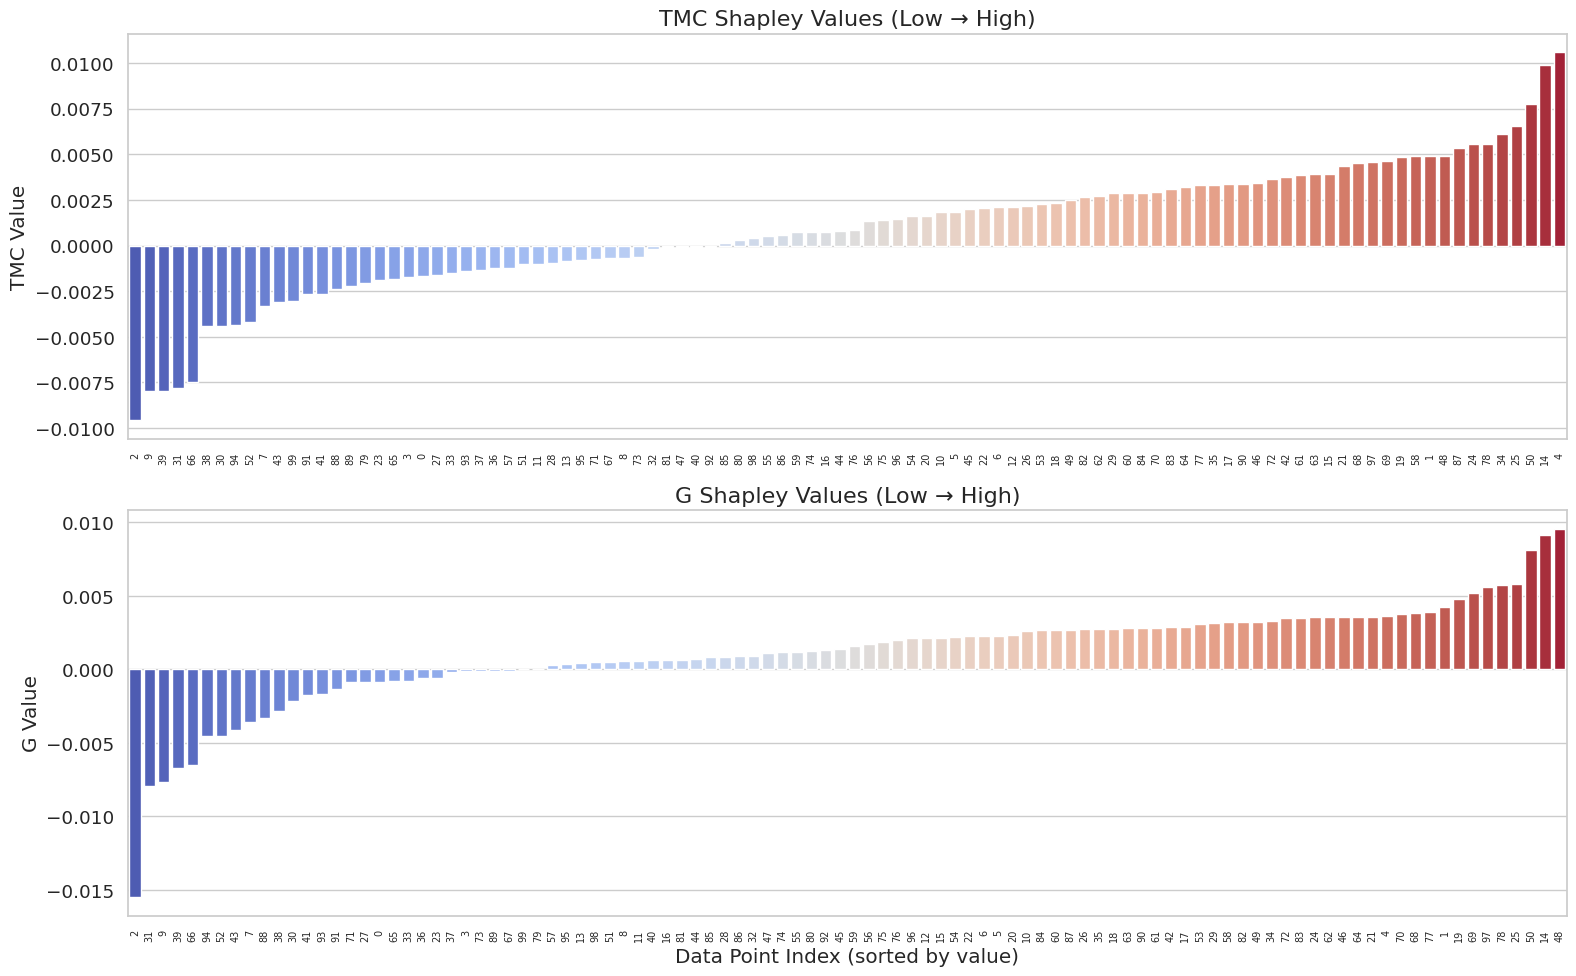

In [14]:
vals_tmc = np.array(dshap.vals_tmc)
vals_g = np.array(dshap.vals_g)
# Create a DataFrame with original indices
df = pd.DataFrame({
    'Index': np.arange(len(vals_tmc)),
    'TMC': vals_tmc,
    'G': vals_g
})
# Initialize Seaborn style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
# Create figure with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
# --- TMC sorted (low → high) ---
df_sorted_tmc = df.sort_values(by='TMC', ascending=True).reset_index(drop=True)
sns.barplot(x=df_sorted_tmc.index, y='TMC', data=df_sorted_tmc, palette='coolwarm', ax=axes[0])
axes[0].set_title("TMC Shapley Values (Low → High)", fontsize=16)
axes[0].set_ylabel("TMC Value")
axes[0].set_xlabel("")
axes[0].set_xticks(range(len(df_sorted_tmc)))
axes[0].set_xticklabels(df_sorted_tmc['Index'], rotation=90, fontsize=7)
# --- G sorted (low → high) ---
df_sorted_g = df.sort_values(by='G', ascending=True).reset_index(drop=True)
sns.barplot(x=df_sorted_g.index, y='G', data=df_sorted_g, palette='coolwarm', ax=axes[1])
axes[1].set_title("G Shapley Values (Low → High)", fontsize=16)
axes[1].set_ylabel("G Value")
axes[1].set_xlabel("Data Point Index (sorted by value)")
axes[1].set_xticks(range(len(df_sorted_g)))
axes[1].set_xticklabels(df_sorted_g['Index'], rotation=90, fontsize=7)
# Beautify layout
plt.tight_layout()
# Save figure
os.makedirs("synthetic_data_results", exist_ok=True)
plt.savefig("synthetic_data_results/tmc_vs_g_sorted_syn.png", bbox_inches='tight')
plt.show()

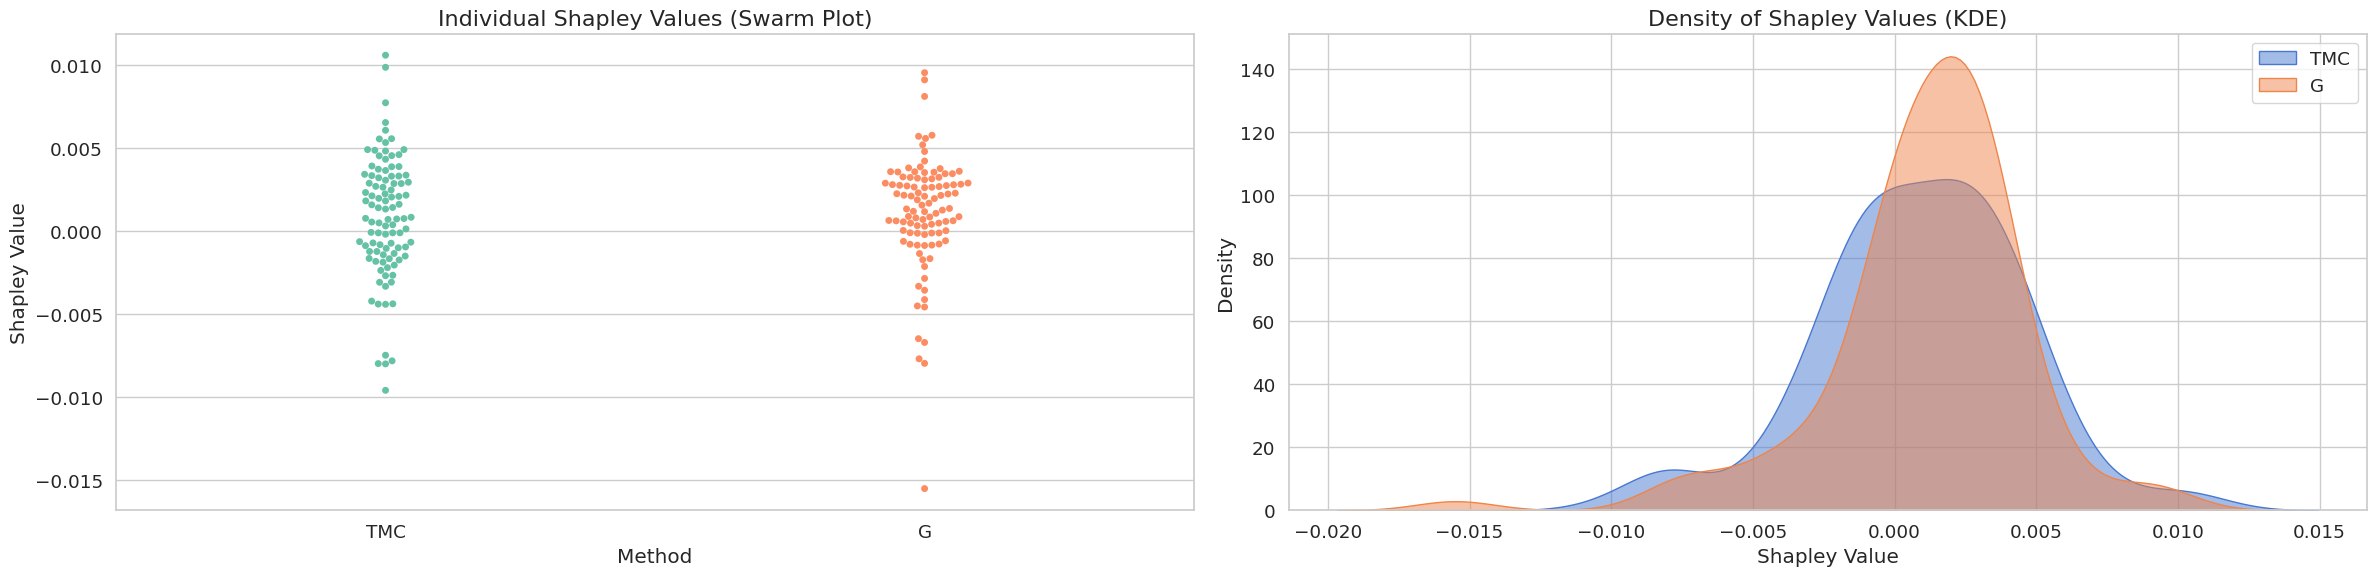

In [10]:
%matplotlib inline
vals_tmc = np.array(dshap.vals_tmc)
vals_g = np.array(dshap.vals_g)
# Create a DataFrame
df = pd.DataFrame({
    'TMC': vals_tmc,
    'G': vals_g,
})
# Set Seaborn style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 6))
# 1. Swarm plot (individual points)
sns.swarmplot(data=df, palette="Set2", size=5, ax=axes[0])
axes[0].set_title("Individual Shapley Values (Swarm Plot)", fontsize=16)
axes[0].set_ylabel("Shapley Value")
axes[0].set_xlabel("Method")
# 2. KDE plot (density estimate)
for method in df.columns:
    sns.kdeplot(df[method], fill=True, label=method, alpha=0.5, ax=axes[1])
axes[1].set_title("Density of Shapley Values (KDE)", fontsize=16)
axes[1].set_ylabel("Density")
axes[1].set_xlabel("Shapley Value")
axes[1].legend()
plt.tight_layout()
# Save figure
output_dir = "synthetic_data_results"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "shapley_plots_syn.png"), bbox_inches='tight')
plt.show()

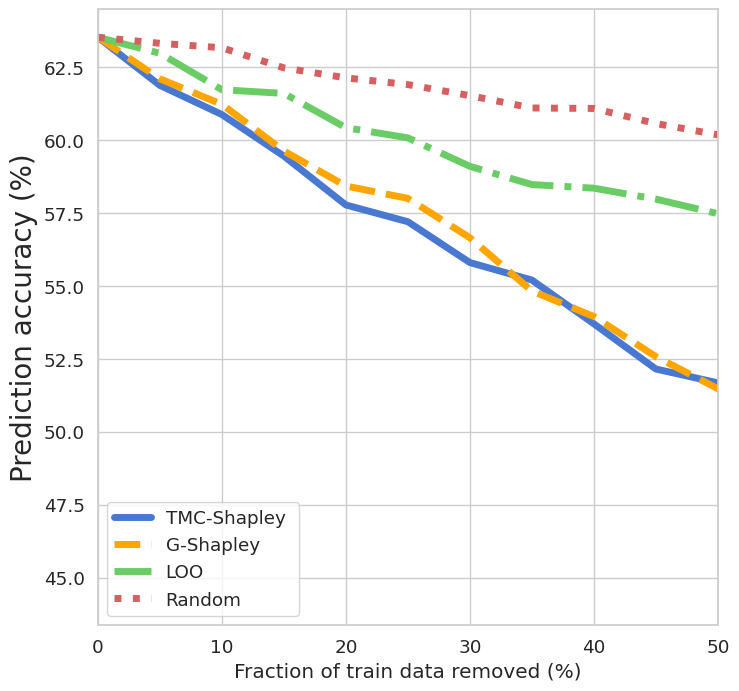

In [11]:
%matplotlib inline
dshap.performance_plots([dshap.vals_tmc, dshap.vals_g, dshap.vals_loo], num_plot_markers=20, sources=dshap.sources)

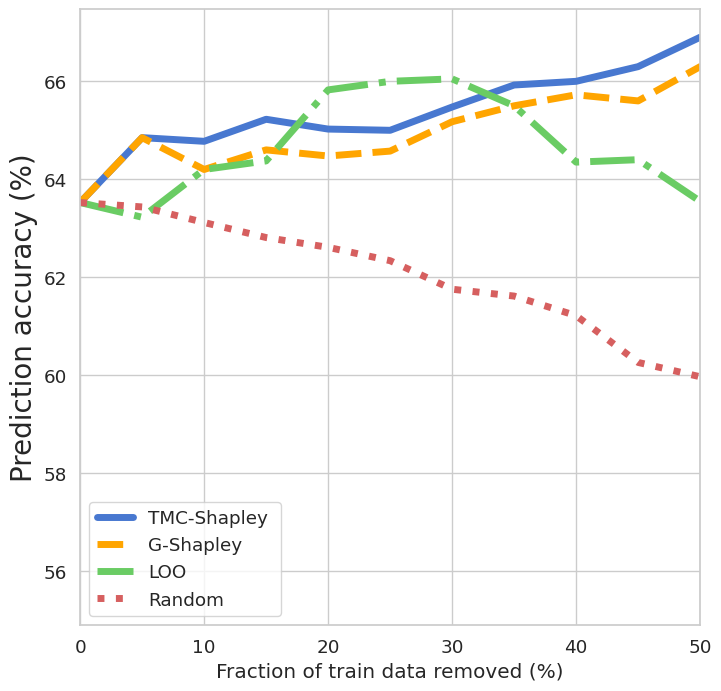

In [12]:
%matplotlib inline
dshap.performance_plots_low_rev([dshap.vals_tmc, dshap.vals_g, dshap.vals_loo], num_plot_markers=20, sources=dshap.sources)